In [1]:
import pandas as pd
data=pd.read_csv('/content/hypertension_dataset.csv')
display(data)

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No
...,...,...,...,...,...,...,...,...,...,...,...
1980,56,10.2,0,Normal,6.5,25.0,Diuretic,Yes,Low,Non-Smoker,Yes
1981,29,8.9,4,Hypertension,6.9,16.9,NaN,Yes,High,Non-Smoker,Yes
1982,64,5.9,9,Normal,5.6,18.9,ACE Inhibitor,Yes,Moderate,Non-Smoker,Yes
1983,35,7.4,8,Prehypertension,8.2,29.2,NaN,Yes,Moderate,Non-Smoker,No


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   object 
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   object 
 7   Family_History    1985 non-null   object 
 8   Exercise_Level    1985 non-null   object 
 9   Smoking_Status    1985 non-null   object 
 10  Has_Hypertension  1985 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 170.7+ KB


In [3]:
data.isnull().sum()

,0
Age,0
Salt_Intake,0
Stress_Score,0
BP_History,0
Sleep_Duration,0
BMI,0
Medication,799
Family_History,0
Exercise_Level,0
Smoking_Status,0


Text(0.5, 1.0, 'medication')

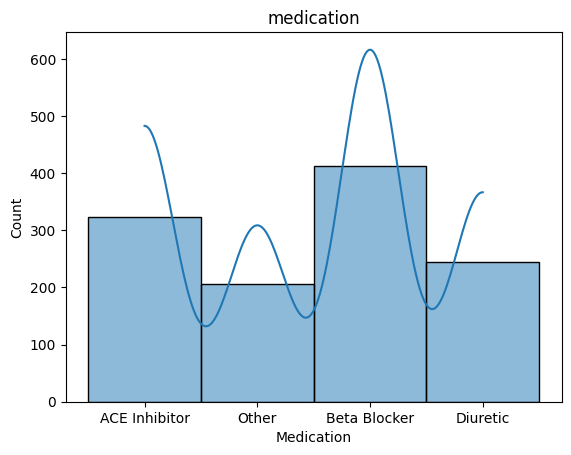

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.histplot(data['Medication'],kde=True)
plt.title('medication')

In [5]:
data['Medication']=data['Medication'].fillna(data['Medication'].mode()[0])

In [6]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1980,False
1981,False
1982,False
1983,False


In [7]:
data.describe()

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,50.341058,8.531688,4.979345,6.452242,26.015315
std,19.442042,1.994907,3.142303,1.542207,4.512857
min,18.000000,2.500000,0.000000,1.500000,11.900000
25%,34.000000,7.200000,2.000000,5.400000,23.000000
50%,50.000000,8.500000,5.000000,6.500000,25.900000
75%,67.000000,9.900000,8.000000,7.500000,29.100000
max,84.000000,16.400000,10.000000,11.400000,41.900000


In [8]:
box_=['Age','Salt_Intake','Stress_Score','Sleep_Duration','BMI']

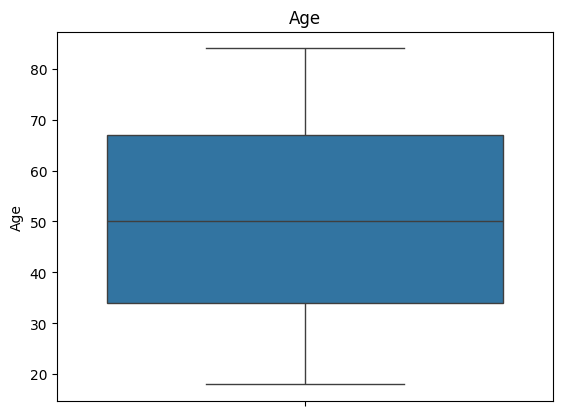

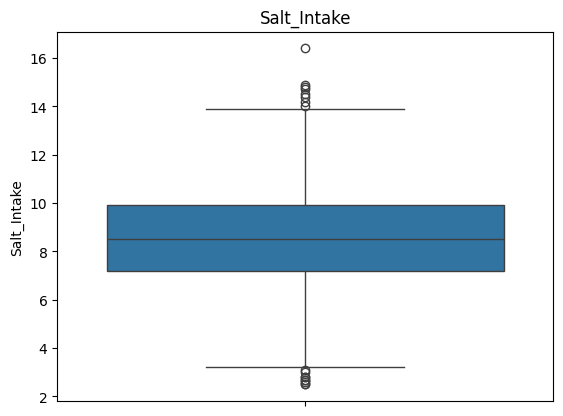

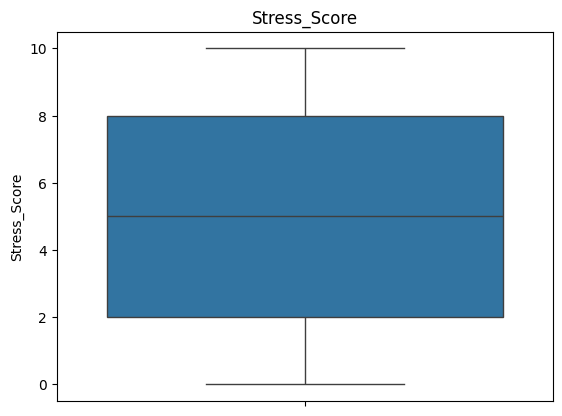

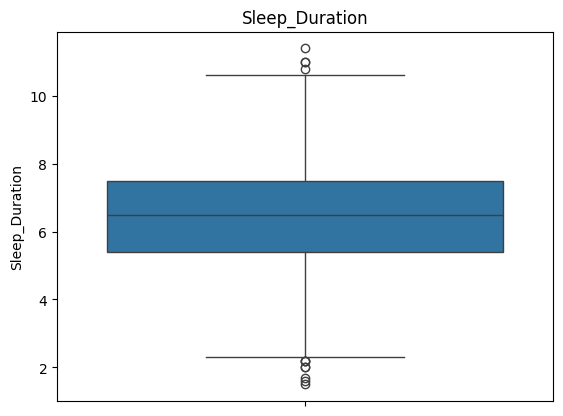

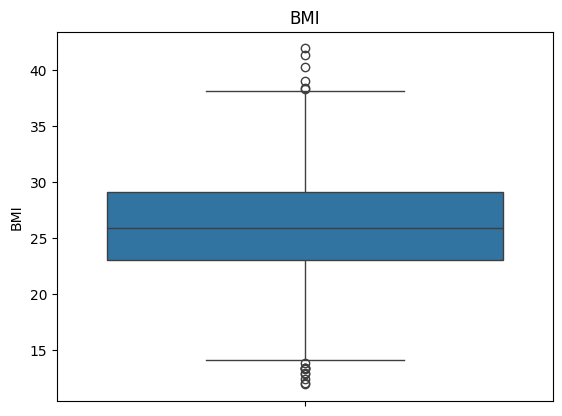

In [9]:
for i in box_:
  plt.title(i)
  sns.boxplot(data[i])
  plt.show()


In [10]:
out_li=['BMI','Sleep_Duration','Salt_Intake']

In [11]:
for o in out_li:
  Q1 = data[o].quantile(0.25)
  Q3 = data[o].quantile(0.75)
  IQR = Q3 - Q1

  # Define bounds for non-outliers
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # Keep only rows within bounds
  data= data[(data[o] >= lower_bound) & (data[o] <= upper_bound)]

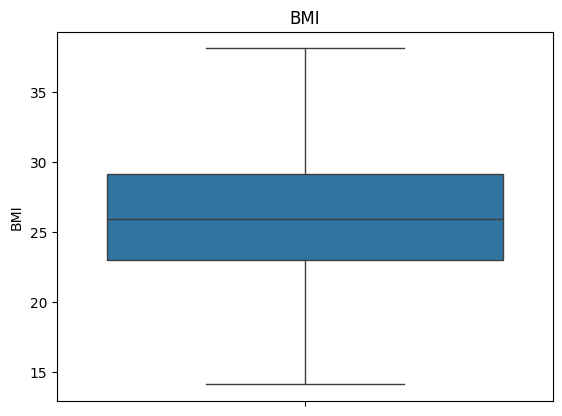

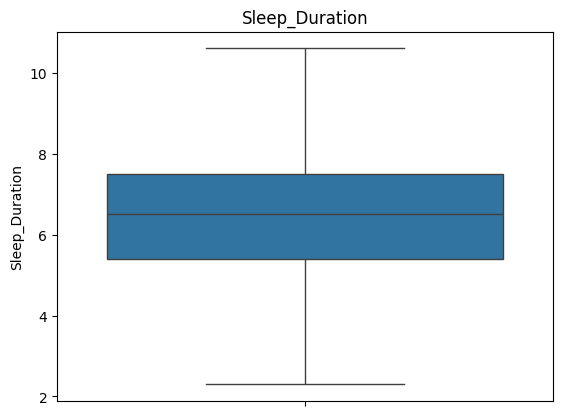

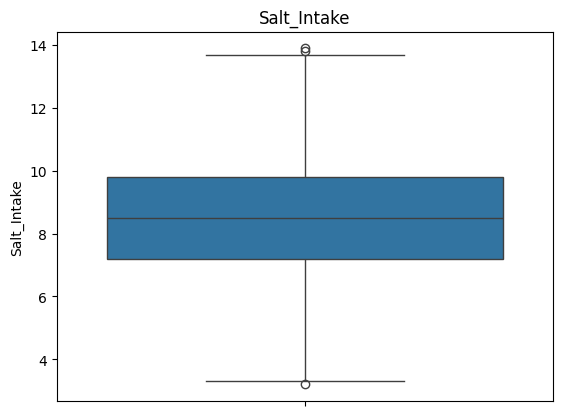

In [12]:
for i in out_li:
  plt.title(i)
  sns.boxplot(data[i])
  plt.show()

In [13]:
data

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,Beta Blocker,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,Beta Blocker,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,Beta Blocker,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No
...,...,...,...,...,...,...,...,...,...,...,...
1980,56,10.2,0,Normal,6.5,25.0,Diuretic,Yes,Low,Non-Smoker,Yes
1981,29,8.9,4,Hypertension,6.9,16.9,Beta Blocker,Yes,High,Non-Smoker,Yes
1982,64,5.9,9,Normal,5.6,18.9,ACE Inhibitor,Yes,Moderate,Non-Smoker,Yes
1983,35,7.4,8,Prehypertension,8.2,29.2,Beta Blocker,Yes,Moderate,Non-Smoker,No


In [14]:
features=data.drop(columns='Has_Hypertension')

In [15]:
target=data['Has_Hypertension']

In [16]:
cat_cols=['BP_History','Medication','Family_History','Exercise_Level','Smoking_Status']

In [17]:
for c in cat_cols:
  ca=data.value_counts(c)
  display(ca)

,count
BP_History,
Normal,779
Prehypertension,604
Hypertension,558


,count
Medication,
Beta Blocker,1185
ACE Inhibitor,311
Diuretic,242
Other,203


,count
Family_History,
No,977
Yes,964


,count
Exercise_Level,
Low,918
Moderate,645
High,378


,count
Smoking_Status,
Non-Smoker,1388
Smoker,553


In [18]:
data.shape

(1941, 11)

In [19]:
from sklearn.preprocessing import OneHotEncoder
on=OneHotEncoder(sparse_output=False,drop='first')

for n in cat_cols:
  dat=on.fit_transform(data[[n]])

  # Create DataFrame da with the same index as data to ensure correct alignment
  da=pd.DataFrame(dat,columns=on.get_feature_names_out(), index=data.index)


  features=pd.concat([features,da],axis=1)
  features=features.drop(columns=n)

display(features)

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI,BP_History_Normal,BP_History_Prehypertension,Medication_Beta Blocker,Medication_Diuretic,Medication_Other,Family_History_Yes,Exercise_Level_Low,Exercise_Level_Moderate,Smoking_Status_Smoker
0,69,8.0,9,6.4,25.8,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,32,11.7,10,5.4,23.4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,78,9.5,3,7.1,18.7,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,38,10.0,10,4.2,22.1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,41,9.8,1,5.8,16.2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1980,56,10.2,0,6.5,25.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
1981,29,8.9,4,6.9,16.9,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1982,64,5.9,9,5.6,18.9,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1983,35,7.4,8,8.2,29.2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [20]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(features,target,test_size=0.2,random_state=42)


In [21]:
from sklearn.linear_model import  LogisticRegression
le=LogisticRegression()
le.fit(xtrain,ytrain)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [22]:
ypred=le.predict(xtest)

In [23]:
from sklearn.metrics import classification_report,accuracy_score
print(classification_report(ypred,ytest))
print(accuracy_score(ypred,ytest))

              precision    recall  f1-score   support

          No       0.90      0.86      0.88       200
         Yes       0.86      0.90      0.88       189

    accuracy                           0.88       389
   macro avg       0.88      0.88      0.88       389
weighted avg       0.88      0.88      0.88       389

0.8791773778920309


In [24]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(xtrain,ytrain)

KNeighborsClassifier()

In [25]:
ypred=knn.predict(xtest)

In [26]:
from sklearn.metrics import accuracy_score, classification_report
print(accuracy_score(ypred,ytest))
print(classification_report(ypred,ytest))

0.6169665809768637
              precision    recall  f1-score   support

          No       0.63      0.61      0.62       198
         Yes       0.61      0.63      0.62       191

    accuracy                           0.62       389
   macro avg       0.62      0.62      0.62       389
weighted avg       0.62      0.62      0.62       389



In [27]:
from sklearn.svm import SVC
sv=SVC()
sv.fit(xtrain,ytrain)

SVC()

In [28]:
ypred=sv.predict(xtest)

In [29]:
from sklearn.metrics import accuracy_score,classification_report
print(accuracy_score(ypred,ytest))
print(classification_report(ypred,ytest))

0.622107969151671
              precision    recall  f1-score   support

          No       0.62      0.61      0.62       192
         Yes       0.63      0.63      0.63       197

    accuracy                           0.62       389
   macro avg       0.62      0.62      0.62       389
weighted avg       0.62      0.62      0.62       389



In [30]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
dtc.fit(xtrain,ytrain)

DecisionTreeClassifier()

In [31]:
ypred=dtc.predict(xtest)

In [32]:
from sklearn.metrics import accuracy_score,classification_report
print(accuracy_score(ypred,ytest))
print(classification_report(ypred,ytest))

0.9048843187660668
              precision    recall  f1-score   support

          No       0.91      0.90      0.90       192
         Yes       0.90      0.91      0.91       197

    accuracy                           0.90       389
   macro avg       0.90      0.90      0.90       389
weighted avg       0.90      0.90      0.90       389



In [38]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier




In [39]:
rf=RandomForestClassifier(random_state=42)
param_grid={ 'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
            }

grid_search = GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,n_jobs=-1,scoring='accuracy')

grid_search.fit(xtrain, ytrain)
print("Best parameters from GridSearchCV:", grid_search.best_params_)
print("Best accuracy from GridSearchCV:", grid_search.best_score_)



Best parameters from GridSearchCV: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best accuracy from GridSearchCV: 0.958132973757909
